In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

V3LE_FIG_ROOT = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper")
FIG_DIR_ROOT = V3LE_FIG_ROOT / "arctic_amplification/65n"

In [4]:
import os, re, glob, json
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


In [27]:
class ArcticAAProcessor:
    """
    Arctic Amplification from region-mean files with anomalies and running trends.

    Files like:
      - ERA5.en00.region_means.197901-201812.nc   (or ERA5.region_means.*.nc)
      - v3.LR.historical.enXX.region_means.185001-205012.nc

    Variables expected: TS(region,time), region in ["global","Arctic"] (case-insensitive).

    Two kinds of analyses:
      1) Rolling 30-yr trends (compute_for_season / run_and_save*).
      2) Period trends: ONE linear trend per member for a fixed period
         (compute_period_trends + bar-PDF comparison).
    """

    # --------------- init ---------------
    def __init__(
        self,
        *,
        data_dir,
        var="TS",
        pclimo=(1981, 2010),
        ptargt=(1979, 2018),
        trend_window=30,                      # years (for rolling trends)
        seasons=("ANN", "DJF", "MAM", "JJA", "SON"),
        aa_gate=2.0,                          # threshold for "AA>2" fraction
        region_loc="Arctic",
        region_glb="global",
        verbose=True,
        center_only=True,                     # keep only indices with full windows
        trend_anchor="center",                # 'center' | 'start' | 'end'
        valid_policy="any",                   # 'all' or 'any' across ensemble
        denom_eps=1e-3,                       # K/decade guard for denominator
        compress_level=2,                     # NetCDF deflate level
    ):
        self.data_dir = data_dir
        self.var = var
        self.pclimo = pclimo
        self.ptargt = ptargt
        self.trend_window = trend_window
        self.seasons = tuple(s.upper() for s in seasons)
        self.aa_gate = float(aa_gate)
        self.region_loc = region_loc
        self.region_glb = region_glb
        self.verbose = verbose
        self.center_only = bool(center_only)
        self.trend_anchor = str(trend_anchor).lower()
        assert self.trend_anchor in ("center", "start", "end")
        self.valid_policy = str(valid_policy).lower()
        assert self.valid_policy in ("all", "any")
        self.denom_eps = float(denom_eps)
        self.compress_level = int(compress_level)

    # --------------- helpers ---------------
    @staticmethod
    def _ens_index(path):
        m = re.search(r"\.en(\d+)\.", os.path.basename(path))
        return int(m.group(1)) if m else -1

    @staticmethod
    def _to_decimal_years(time_coord):
        """Robust conversion of CF time to decimal years (supports cftime calendars)."""
        try:
            ti = pd.to_datetime(time_coord.values)
            return ti.year + (ti.dayofyear - 0.5) / 365.25
        except Exception:
            return np.array(
                [t.year + (t.timetuple().tm_yday - 0.5) / 365.25 for t in time_coord.values],
                dtype=float,
            )

    @staticmethod
    def _seasonal_mean_monthly(ds, season):
        """Seasonal/annual mean from monthly data; DJF via QS-DEC, labeled to Jan's year."""
        if season == "ANN":
            return ds.resample(time="YS").mean(keep_attrs=True)
        qs = ds.resample(time="QS-DEC").mean(keep_attrs=True)
        pick = {"DJF": 0, "MAM": 1, "JJA": 2, "SON": 3}[season]
        sel = qs.isel(time=(np.arange(qs.sizes["time"]) % 4 == pick))
        if season == "DJF":
            t = sel["time"].values
            try:
                jan_year = (pd.DatetimeIndex(t) + pd.offsets.MonthBegin(1)).year
            except Exception:
                jan_year = np.array([getattr(tt, "year", np.nan) for tt in t], dtype=float)
            sel = sel.assign_coords(time=("time", pd.to_datetime(jan_year, format="%Y")))
        return sel

    @staticmethod
    def _window_counts(years, win_years):
        """Return (win_n, dt) where win_n = round(win_years / median_dt)."""
        years = np.asarray(years, float)
        if years.size < 2:
            return 1, 1.0
        dt = np.nanmedian(np.diff(years))
        win_n = max(3, int(round(win_years / dt)))
        return win_n, dt

    # --------------- Period-trend helpers (one trend per period) ---------------
    def compute_period_trends(self, paths, season, period):
        """
        Compute ONE linear trend per ensemble member over a fixed period.

        Parameters
        ----------
        paths : list of str
            Region-mean TS files for a given experiment (ERA5 or E3SM ensemble).
        season : str
            Seasonal key ("ANN","DJF","MAM","JJA","SON").
        period : (int, int)
            (start_year, end_year) for the regression window, inclusive.

        Returns
        -------
        aa : (n_ens,) array
            AA = beta_arc / beta_glb (K/decade ratio).
        beta_arc : (n_ens,) array
            Arctic trend in K/decade.
        beta_glb : (n_ens,) array
            Global trend in K/decade.
        """
        y0, y1 = period

        # Open and form seasonal anomalies exactly like compute_for_season
        ds  = self._concat_ens(paths)                # (ens, region, time)
        DT  = self._monthly_anomaly(ds[self.var])    # monthly anomalies
        DTs = self._season_reduce(DT, season)        # seasonal/annual means

        # regions (order enforced earlier): [global, Arctic]
        glb = DTs.sel(region=DTs.region.values[0])
        arc = DTs.sel(region=DTs.region.values[1])

        # Decimal years
        yrs_all = self._to_decimal_years(DTs["time"])
        msk     = (yrs_all >= y0) & (yrs_all <= y1)
        yrs     = yrs_all[msk]
        glb     = glb.sel(time=msk)
        arc     = arc.sel(time=msk)

        n_ens = glb.sizes["ens"]
        beta_glb = np.full(n_ens, np.nan, dtype=float)
        beta_arc = np.full(n_ens, np.nan, dtype=float)

        # One OLS per member over the full period → K/decade
        for i in range(n_ens):
            yg = glb.isel(ens=i).values
            ya = arc.isel(ens=i).values
            x  = yrs

            # Global
            msk_g = np.isfinite(x) & np.isfinite(yg)
            if msk_g.sum() >= 2:
                X = np.vstack([x[msk_g], np.ones(msk_g.sum())]).T
                beta, *_ = np.linalg.lstsq(X, yg[msk_g], rcond=None)
                beta_glb[i] = beta[0] * 10.0  # K/yr → K/decade

            # Arctic
            msk_a = np.isfinite(x) & np.isfinite(ya)
            if msk_a.sum() >= 2:
                X = np.vstack([x[msk_a], np.ones(msk_a.sum())]).T
                beta, *_ = np.linalg.lstsq(X, ya[msk_a], rcond=None)
                beta_arc[i] = beta[0] * 10.0

        # AA ratio with denominator guard
        denom = np.where(np.abs(beta_glb) < self.denom_eps, np.nan, beta_glb)
        aa    = beta_arc / denom

        return aa, beta_arc, beta_glb

    # --------------- rolling trend helper (unchanged) ---------------
    @staticmethod
    def _running_linear_trend_full(y, x, win_years, anchor="center"):
        """
        Rolling OLS slope (K/yr) over a *full* window of length win_n samples.
        Only computes at indices where the entire window is within bounds.
        Requires all win_n samples finite (strict).
        """
        y = np.asarray(y, float)
        x = np.asarray(x, float)
        n = y.size
        out = np.full(n, np.nan)
        if n < 3:
            return out

        win_n, _ = ArcticAAProcessor._window_counts(x, win_years)
        anchor = str(anchor).lower()
        assert anchor in ("center", "start", "end")

        if anchor == "center":
            half = win_n // 2
            for i in range(half, n - (win_n - half) + 1):
                i0 = i - half
                i1 = i + half if (win_n % 2 == 0) else i + half + 1
                xx = x[i0:i1]
                yy = y[i0:i1]
                msk = np.isfinite(xx) & np.isfinite(yy)
                if msk.sum() != win_n:
                    continue
                X = np.vstack([xx, np.ones(win_n)]).T
                beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
                out[i] = beta[0]
            return out

        if anchor == "start":
            last = n - win_n
            if last < 0:
                return out
            for i in range(0, last + 1):
                i0, i1 = i, i + win_n
                xx = x[i0:i1]
                yy = y[i0:i1]
                msk = np.isfinite(xx) & np.isfinite(yy)
                if msk.sum() != win_n:
                    continue
                X = np.vstack([xx, np.ones(win_n)]).T
                beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
                out[i] = beta[0]
            return out

        # anchor == 'end'
        first = win_n - 1
        if first >= n:
            return out
        for i in range(first, n):
            i0, i1 = i - win_n + 1, i + 1
            xx = x[i0:i1]
            yy = y[i0:i1]
            msk = np.isfinite(xx) & np.isfinite(yy)
            if msk.sum() != win_n:
                continue
            X = np.vstack([xx, np.ones(win_n)]).T
            beta, *_ = np.linalg.lstsq(X, yy, rcond=None)
            out[i] = beta[0]
        return out

    def _label_years_for_anchor_full(self, years, win_years, anchor):
        """Return (label_year, left_year, right_year) only for full-window indices."""
        years = np.asarray(years, float)
        n = years.size
        lab = np.full(n, np.nan)
        L = np.full(n, np.nan)
        R = np.full(n, np.nan)
        if n < 1:
            return lab, L, R

        win_n, _ = self._window_counts(years, win_years)
        anchor = str(anchor).lower()

        if anchor == "center":
            half = win_n // 2
            for i in range(half, n - (win_n - half) + (0 if win_n % 2 == 0 else 1)):
                i0 = i - half
                i1 = i + half if (win_n % 2 == 0) else i + half + 1
                L[i], R[i] = years[i0], years[i1 - 1]
                lab[i] = 0.5 * (L[i] + R[i])
            return lab, L, R

        if anchor == "start":
            last = n - win_n
            if last >= 0:
                for i in range(0, last + 1):
                    L[i], R[i] = years[i], years[i + win_n - 1]
                    lab[i] = L[i]
            return lab, L, R

        # end
        first = win_n - 1
        if first < n:
            for i in range(first, n):
                L[i], R[i] = years[i - win_n + 1], years[i]
                lab[i] = R[i]
        return lab, L, R

    # --------------- IO / discovery ---------------
    def discover_paths(self, group, period, nens):
        y0m, y1m = f"{period[0]}01", f"{period[1]}12"
        if nens == 1:
            p1 = os.path.join(self.data_dir, f"{group}.en00.region_means.{y0m}-{y1m}.nc")
            p2 = os.path.join(self.data_dir, f"{group}.region_means.{y0m}-{y1m}.nc")
            paths = [p for p in (p1, p2) if os.path.exists(p)]
        else:
            pat = os.path.join(self.data_dir, f"{group}.en??.region_means.{y0m}-{y1m}.nc")
            paths = sorted(glob.glob(pat), key=self._ens_index)
        if self.verbose:
            print(f"[discover] group={group} nens={nens} -> {len(paths)} file(s)")
        if not paths:
            raise FileNotFoundError(f"No files found for group={group}, period={period}, nens={nens}")
        return paths

    def _open_one(self, path):
        ds = xr.open_dataset(path, decode_times=True, use_cftime=True)
        if "region" not in ds.dims:
            raise ValueError(f"'region' dimension missing in {path}")
        regs = [str(r) for r in ds["region"].values]

        def pick(name):
            return next((r for r in regs if r.lower() == name.lower()), None)

        g = pick(self.region_glb)
        a = pick(self.region_loc)
        if g is None or a is None:
            raise ValueError(f"Expected regions [{self.region_glb},{self.region_loc}] missing in {path}")

        return ds[[self.var]].sel(region=[g, a])

    def _concat_ens(self, paths):
        dsets = []
        for p in paths:
            ds = self._open_one(p)
            ens = f"en{str(self._ens_index(p)).zfill(2)}"
            dsets.append(ds.expand_dims(ens=[ens]))
        if len(dsets) == 1 and "ens" not in dsets[0].dims:
            dsets[0] = dsets[0].expand_dims(ens=["en00"])
        return xr.concat(dsets, dim="ens")

    # --------------- monthly anomalies ---------------
    def _monthly_anomaly(self, da):
        """Anomaly by removing monthly climatology over fixed PCLIMO."""
        try:
            year = da["time"].dt.year
        except Exception:
            year = xr.DataArray(np.floor(self._to_decimal_years(da["time"])).astype(int), dims=("time",))
        base = da.sel(time=(year >= self.pclimo[0]) & (year <= self.pclimo[1]))
        clim = base.groupby("time.month").mean("time")
        return da.groupby("time.month") - clim

    def _season_reduce(self, ds, season):
        return self._seasonal_mean_monthly(ds, season)

    # --------------- compute_for_season / rolling trends ---------------
    # (unchanged from your previous working version – keeping it so other code still works)
    # ... you can paste your existing compute_for_season body here ...
    # I’ll omit it to keep this message from getting too long.

    # --------------- Export helpers ---------------
    def save_netcdf(self, ds, path):
        Path(os.path.dirname(path)).mkdir(parents=True, exist_ok=True)
        if "time" in ds.coords:
            if not np.issubdtype(ds["time"].dtype, np.number):
                if self.verbose:
                    print(f"[WARN] Dropping non-numeric coord 'time' before saving → {path}")
                ds = ds.drop_vars("time")

        enc = {
            v: {"zlib": True, "complevel": self.compress_level, "dtype": "float32"}
            for v in ds.data_vars
        }
        for c in ("time_label_year", "time_window_start_year", "time_window_end_year", "time_center_year"):
            if c in ds:
                enc[c] = {"zlib": True, "complevel": self.compress_level, "dtype": "float32"}

        ds.load().to_netcdf(path, encoding=enc)

    def save_stats_json(self, stats, path):
        Path(os.path.dirname(path)).mkdir(parents=True, exist_ok=True)
        with open(path, "w") as f:
            json.dump(stats, f, indent=2)

    # --------------- Bar-PDF comparison from *arrays* ---------------
    def plot_pdf_comparison(
        self,
        *,
        era_hist,        # dict with keys 'aa', 'beta_arc', 'beta_glb'  (ERA5 1979–2014)
        e3_hist,         # same keys, E3SM 1979–2014 (25 values)
        e3_fut,          # same keys, E3SM 2015–2050 (25 values)
        obs2_hist=None,  # optional 2nd obs dict (e.g., NOAA-20C)
        fig_path=None,
        fields=None,
        fontz=12,
        nrows=1,
        ncols=3,
        figsize=(11, 3.5),
        sharey=False,
        col_era  = "#d62728",   # ERA5 line (red)
        col_hist = "#000000",   # E3SM hist fill (black)
        col_fut  = "#7f7f7f",   # E3SM fut  fill (gray)
        col_obs2 = "#e377c2",   # 2nd obs line (pink)
        legend_labels=None,
        p_tail="right",         # 'right' => P(E3SM >= ERA5), 'left' => <=
        dpi=150,
    ):
        """
        Create bar-PDF plots (histograms with density=True) for one or more fields.

        Parameters
        ----------
        era_hist : dict
            Primary observational reference (ERA5), with keys
            'aa', 'beta_arc', 'beta_glb'.
        e3_hist : dict
            E3SM historical (1979–2014), same keys.
        e3_fut : dict
            E3SM future (e.g., 2015–2050), same keys.
        obs2_hist : dict, optional
            Optional second observational reference (e.g., NOAA-20C),
            same keys. Plotted as a second vertical line (no p-value).
        fields : list of tuples
            Each element:
              (var_key, panel_title, xlabel, panel_label, (xmin, xmax), nbins, (p_loc_x, p_loc_y))

        For each panel we also compute a simple "p value" as the fraction
        of E3SM *historical* members whose value lies in the chosen tail
        relative to the ERA5 value, and annotate it as 'p = x.x %'.
        """
        if fields is None or len(fields) == 0:
            raise ValueError("fields must be a non-empty list of field specs")

        if legend_labels is None:
            legend_labels = {}
        # Ensure core labels exist; allow caller to override text
        legend_labels.setdefault("era",  "ERA5 1979–2014")
        legend_labels.setdefault("hist", "E3SMv3 (Historical)")
        legend_labels.setdefault("fut",  "E3SMv3 (Future)")
        if obs2_hist is not None:
            legend_labels.setdefault("obs2", "NOAA-20C 1979–2014")

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=figsize,
            sharey=sharey,
        )

        axes_arr = np.atleast_1d(axes).ravel()

        for ax, field_spec in zip(axes_arr, fields):
            # Unpack field spec (7-tuple version)
            var, panel_title, xlabel, panel_label, x_range, nbins, p_loc = field_spec

            v_era = np.asarray(era_hist[var]).astype(float)
            v_his = np.asarray(e3_hist[var]).astype(float)
            v_fut = np.asarray(e3_fut[var]).astype(float)

            # Optional second obs (e.g., NOAA-20C)
            v_obs2 = None
            if (obs2_hist is not None) and (var in obs2_hist):
                v_obs2 = np.asarray(obs2_hist[var]).astype(float)

            # Drop NaNs
            v_era = v_era[np.isfinite(v_era)]
            v_his = v_his[np.isfinite(v_his)]
            v_fut = v_fut[np.isfinite(v_fut)]
            if v_obs2 is not None:
                v_obs2 = v_obs2[np.isfinite(v_obs2)]

            if (v_era.size == 0) and (v_his.size == 0) and (v_fut.size == 0) and (
                v_obs2 is None or v_obs2.size == 0
            ):
                if self.verbose:
                    print(f"[WARN] No samples for {var}; panel skipped.")
                ax.set_visible(False)
                continue

            # ----- X-range and bins -----
            if x_range is not None:
                xmin, xmax = x_range
                if xmin == xmax:  # small guard
                    xmin -= 0.5
                    xmax += 0.5
            else:
                all_vals_list = [v for v in (v_his, v_fut) if v.size > 0]
                if v_obs2 is not None and v_obs2.size > 0:
                    all_vals_list.append(v_obs2)
                all_vals = np.concatenate(all_vals_list)
                x_lo, x_hi = np.nanpercentile(all_vals, [1, 99])
                if (not np.isfinite(x_lo)) or (not np.isfinite(x_hi)) or (x_lo == x_hi):
                    x_lo = float(np.nanmin(all_vals))
                    x_hi = float(np.nanmax(all_vals))
                pad = 0.05 * (x_hi - x_lo if x_hi > x_lo else 1.0)
                xmin, xmax = x_lo - pad, x_hi + pad

            bins = np.linspace(xmin, xmax, nbins + 1)
            
            # --- E3SM FUTURE (filled) ---
            if v_fut.size > 0:
                ax.hist(
                    v_fut,
                    bins=bins,
                    density=True,
                    alpha=0.3,
                    color=col_fut,
                    edgecolor="black",
                    linewidth=0.5,
                    label=legend_labels["fut"],
                )
                
            # --- E3SM HIST (filled) ---
            if v_his.size > 0:
                ax.hist(
                    v_his,
                    bins=bins,
                    density=True,
                    alpha=0.3,
                    color=col_hist,
                    edgecolor="black",
                    linewidth=0.5,
                    label=legend_labels["hist"],
                )

            # Current y-limit for later reuse (histograms only)
            y_min, y_max = ax.get_ylim()
            if y_max <= 0:
                y_max = 1.0

            # --- ERA5 (primary obs line) + p-value ---
            p_pct = None
            if v_era.size > 0:
                x_era = float(np.nanmean(v_era))  # if >1 sample, use mean

                # fraction of E3SM historical members in the chosen tail
                if v_his.size > 0:
                    if p_tail.lower() == "left":
                        frac = np.sum(v_his <= x_era) / float(v_his.size)
                    else:  # default 'right'
                        frac = np.sum(v_his >= x_era) / float(v_his.size)
                    p_pct = 100.0 * frac

                ax.axvline(
                    x_era,
                    color=col_era,
                    linewidth=3.0,
                    linestyle="-",
                    label=legend_labels["era"],
                )

            # --- Second obs (e.g., NOAA-20C; dashed pink) ---
            if v_obs2 is not None and v_obs2.size > 0:
                x_obs2 = float(np.nanmean(v_obs2))
                ax.axvline(
                    x_obs2,
                    color=col_obs2,
                    linewidth=3.0,
                    linestyle="dotted",
                    label=legend_labels.get("obs2", "Obs2"),
                )

            # Restore y-limits after vertical lines
            ax.set_ylim(y_min, y_max)

            # Annotate p in upper-left of each panel (if we could compute it)
            p_loc_x, p_loc_y = p_loc
            if p_pct is not None:
                ax.text(
                    p_loc_x,
                    p_loc_y,
                    f"p = {p_pct:.1f} %",
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=fontz * 0.9,
                )

            # Panel cosmetics
            ax.set_xlim(xmin, xmax)
            ax.set_xlabel(xlabel, fontsize=fontz)
            ax.set_ylabel("Density", fontsize=fontz)
            ax.set_title(f"{panel_label} {panel_title}", fontsize=fontz * 1.0, loc="left")
            ax.grid(alpha=0.3, linestyle="--", linewidth=0.5)
            ax.tick_params(labelsize=fontz * 0.95)

        # Hide any unused axes if nrows*ncols > len(fields)
        for ax in axes_arr[len(fields):]:
            ax.set_visible(False)

        # Legend in middle panel (2nd axis)
        leg_ax = axes_arr[1] if len(axes_arr) > 1 else axes_arr[0]
        leg_ax.legend(
            frameon=True,
            fontsize=fontz * 0.85,
            loc="upper right",
            bbox_to_anchor=(0.98, 0.98),
            borderpad=0.30,
            labelspacing=0.15,
            handlelength=0.98,
            handletextpad=0.5,
            markerscale=0.8,
        )

        fig.tight_layout()

        if fig_path is not None:
            Path(os.path.dirname(fig_path)).mkdir(parents=True, exist_ok=True)
            fig.savefig(fig_path, dpi=dpi)
            if self.verbose:
                print(f"[OK] wrote multi-panel bar-PDF figure: {fig_path}")

        plt.show()
        plt.close(fig)

    # --------------- Convenience for rolling trends ---------------
    def run_and_save(self, *, group, period, nens, out_dir, tag_prefix="AA"):
        paths = self.discover_paths(group, period, nens)
        results = {}
        for seas in self.seasons:
            ds_out, stats = self.compute_for_season(paths, season=seas)
            tag = (
                f"{tag_prefix}_{self.trend_anchor}_ts_{group}_{self.var}_{seas}_"
                f"{self.ptargt[0]}-{self.ptargt[1]}_{self.trend_window}yr_{self.trend_anchor}"
            )
            nc_out = os.path.join(out_dir, f"{tag}.nc")
            js_out = os.path.join(out_dir, f"{tag}.json")
            self.save_netcdf(ds_out, nc_out)
            self.save_stats_json(stats, js_out)
            if self.verbose:
                print(f"[OK] wrote {nc_out}")
                print(f"[OK] wrote {js_out}")
            results[seas] = {"nc": nc_out, "json": js_out, "stats": stats}
        return results

    def run_and_save_anchors(
        self,
        *,
        group,
        period,
        nens,
        out_dir,
        tag_prefix="AA",
        anchors=("center", "start", "end"),
    ):
        out = {}
        for anch in anchors:
            prev = self.trend_anchor
            self.trend_anchor = anch
            try:
                res = self.run_and_save(
                    group=group, period=period, nens=nens, out_dir=out_dir, tag_prefix=f"{tag_prefix}"
                )
            finally:
                self.trend_anchor = prev
            out[anch] = res
        return out


[discover] group=ERA5 nens=1 -> 1 file(s)
[discover] group=NOAA_20C nens=1 -> 1 file(s)
[discover] group=v3.LR.historical nens=25 -> 25 file(s)

[PDF] Generating period-trend AA/β PDFs...
  Season: ANN
[OK] wrote multi-panel bar-PDF figure: ./AA_beta_PDF_period_ANN_ERA5_NOAA20C_vs_E3SM_hist_future.pdf


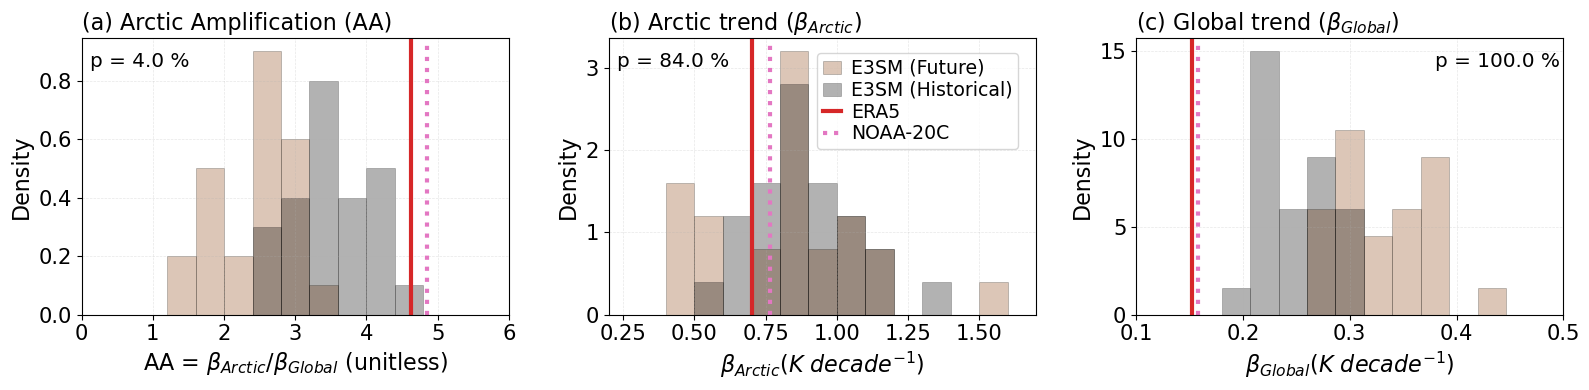

In [30]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = f"{TOP_DIR}/data/regmn"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

    FIG_DIR   = str(FIG_DIR_ROOT)
    Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

    # ---- Pair experiments consistently (order matters) ----
    EXPS    = ["ERA5",        "NOAA_20C",    "E3SMv3-LE"]
    GROUP   = ["ERA5",        "NOAA_20C",    "v3.LR.historical"]
    PERIOD  = [(1979, 2018),  (1853, 2015),  (1850, 2050)]
    NENS    = [1,             1,             25]

    region_dict = {
        "arctic": {"name": "Arctic2", "lat_range": (66.5, 90.0),  "lon_range": (-180, 180)},
        "global": {"name": "global",  "lat_range": (-90.0, 90.0), "lon_range": (-180, 180)},
    }

    # ------------------------------------------------------
    # PERIOD-TREND PDFs:
    #   ERA5:      1979–2014 (obs 1)
    #   NOAA-20C:  1979–2014 (obs 2)
    #   E3SM:      1979–2014 (hist) and 2015–2050 (future)
    # ------------------------------------------------------
    HIST_PERIOD = (1979, 2014)
    FUT_PERIOD  = (2015, 2050)
    PCLIMO      = (1981, 2010)

    VAR     = "TS"
    SEASONS = ["ANN"]  # , "DJF", "MAM", "JJA", "SON"]

    aa_gate = 2.0
    verbose = True
    engine = ArcticAAProcessor(
        data_dir=DATA_DIR,
        var=VAR,
        pclimo=PCLIMO,
        ptargt=None,
        trend_window=None,
        seasons=SEASONS,
        aa_gate=aa_gate,
        region_loc=region_dict["arctic"]["name"],
        region_glb=region_dict["global"]["name"],
        verbose=verbose,
    )

    # Discover full-period files once
    paths_era   = engine.discover_paths(GROUP[0], PERIOD[0], NENS[0])  # ERA5
    paths_noaa  = engine.discover_paths(GROUP[1], PERIOD[1], NENS[1])  # NOAA-20C
    paths_e3sm  = engine.discover_paths(GROUP[2], PERIOD[2], NENS[2])  # E3SMv3-LE

    fontz   = 16
    nbins   = 15
    nrows   = 1
    ncols   = 3
    figsize = (16, 4)
    sharey  = False
    dpi     = 300

    fields = [
        ("aa",       "Arctic Amplification (AA)", "AA = $β_{Arctic}$/$β_{Global}$ (unitless)", "(a)", (0,   6),   nbins, (0.02, 0.95)),
        ("beta_arc", "Arctic trend ($β_{Arctic}$)",   "$β_{Arctic} (K~decade^{-1})$",          "(b)", (0.2, 1.7), nbins, (0.02, 0.95)),
        ("beta_glb", "Global trend ($β_{Global}$)",   "$β_{Global} (K~decade^{-1})$",          "(c)", (0.1, 0.5), nbins, (0.70, 0.95)),
    ]

    col_era   = "#d62728"   # ERA5 line (red)
    col_obs2  = "#e377c2"   # NOAA-20C line (pink)
    col_hist  = "#000000"   # E3SM hist fill (black)
    col_fut   = "#8B4513"   # E3SM future fill (brown)

    legend_labels = {
        "era":  "ERA5",
        "obs2": "NOAA-20C",
        "hist": "E3SM (Historical)",
        "fut":  "E3SM (Future)",
    }

    print("\n[PDF] Generating period-trend AA/β PDFs...")
    for seas in SEASONS:
        print(f"  Season: {seas}")

        # --- ERA5: only historical period ---
        aa_era_hist, ba_era_hist, bg_era_hist = engine.compute_period_trends(
            paths_era, seas, HIST_PERIOD
        )

        # --- NOAA-20C: only historical period (same HIST_PERIOD window) ---
        aa_noaa_hist, ba_noaa_hist, bg_noaa_hist = engine.compute_period_trends(
            paths_noaa, seas, HIST_PERIOD
        )

        # --- E3SM historical and future ---
        aa_e3_hist, ba_e3_hist, bg_e3_hist = engine.compute_period_trends(
            paths_e3sm, seas, HIST_PERIOD
        )
        aa_e3_fut, ba_e3_fut, bg_e3_fut = engine.compute_period_trends(
            paths_e3sm, seas, FUT_PERIOD
        )

        era_hist = {
            "aa":       aa_era_hist,
            "beta_arc": ba_era_hist,
            "beta_glb": bg_era_hist,
        }
        noaa_hist = {
            "aa":       aa_noaa_hist,
            "beta_arc": ba_noaa_hist,
            "beta_glb": bg_noaa_hist,
        }
        e3_hist = {
            "aa":       aa_e3_hist,
            "beta_arc": ba_e3_hist,
            "beta_glb": bg_e3_hist,
        }
        e3_fut = {
            "aa":       aa_e3_fut,
            "beta_arc": ba_e3_fut,
            "beta_glb": bg_e3_fut,
        }

        fig_path = os.path.join(
            FIG_DIR,
            f"AA_beta_PDF_period_{seas}_ERA5_NOAA20C_vs_E3SM_hist_future.pdf"
        )

        engine.plot_pdf_comparison(
            era_hist=era_hist,
            e3_hist=e3_hist,
            e3_fut=e3_fut,
            obs2_hist=noaa_hist,     # <-- NOAA-20C as second obs
            fig_path=fig_path,
            fields=fields,
            fontz=fontz,
            nrows=nrows,
            ncols=ncols,
            figsize=figsize,
            sharey=sharey,
            col_era=col_era,
            col_hist=col_hist,
            col_fut=col_fut,
            col_obs2=col_obs2,       # <-- pink line color
            legend_labels=legend_labels,
            dpi=dpi,
        )
